# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

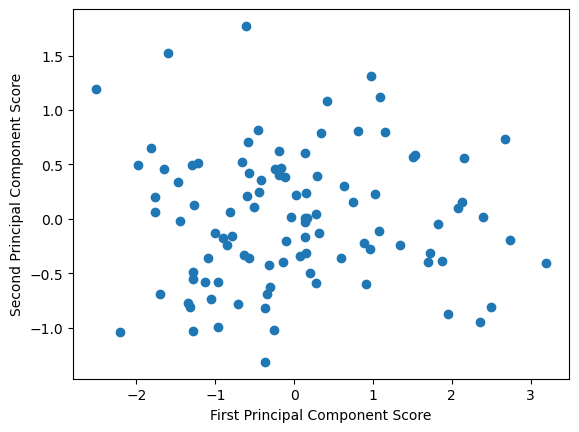

In [51]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [52]:
df = pd.read_csv('DelayData.csv')
df2 = pd.read_csv('T_ONTIME_REPORTING.csv')
df.head()

,depdelay,arrdelay,scheduleddepartdatetime,origin,dest,uniquecarrier,marketshareorigin,marketsharedest,hhiorigin,hhidest,...,windgustdummy,windgustspeed,raindummy,raintracedummy,snowdummy,snowtracedummy,originmetropop,originmetrogdppercapita,destmetropop,destmetrogdppercapita
0,0,-4.0,08-Jan-2004 15:25:00,ELP,SAT,WN,0.618467,0.407567,0.417090,0.226878,...,0,0.0,0,0,0,0,702433,27314.633,1843927,35005.234
1,-4,11.0,22-Jan-2004 14:40:00,ATL,MSY,DL,0.500757,0.096321,0.319589,0.196657,...,0,0.0,0,0,0,0,4802300,49081.773,1314721,48848.234
2,3,12.0,29-Jan-2004 12:25:00,DFW,JFK,DL,0.060898,0.131962,0.296126,0.214357,...,0,0.0,0,0,0,0,5689982,50588.563,18747431,57295.402
3,-3,24.0,14-Jan-2004 15:55:00,SEA,EWR,CO,0.040522,0.347744,0.234712,0.249377,...,0,0.0,1,0,0,0,3163703,57755.547,18747431,57295.402
4,0,-8.0,14-Jan-2004 18:40:00,SLC,RNO,OO,0.506899,0.176493,0.341763,0.277364,...,0,0.0,0,0,0,0,1030597,45043.602,385049,49079.727


**Step 1 - Draw Heatmaps**

Conclusion:
- `distance`, `loadfactor`. `capacity` are related because they structure flights around those three variables
- the obvious correlation is `depdelay` and `arrdelay`, because if a plane departs late, it will arrive late and vice versa
- interestingly, there there is hardly any correlation between the delay variables and the flight characteristics

Text(0.5, 1.0, 'Correlation Matrix of Passenger Variables')

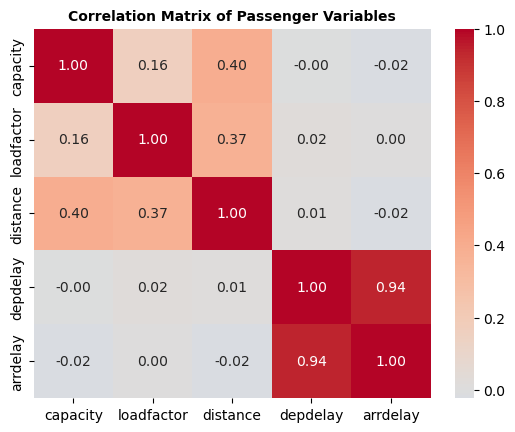

In [53]:
passenger_cols = ['capacity','loadfactor','distance','depdelay','arrdelay']


import seaborn as sns
corr = df[passenger_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Passenger Variables', fontweight='bold', fontsize='medium')

Text(0.5, 1.0, 'FIGURE 1: Correlation Matrix of Departure Variables')

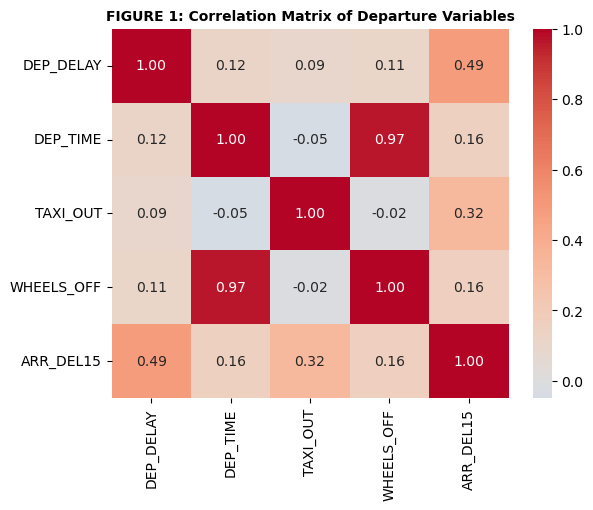

In [75]:
passenger_cols = ['DEP_DELAY','DEP_TIME','TAXI_OUT','WHEELS_OFF','ARR_DEL15']


import seaborn as sns
corr = df2[passenger_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('FIGURE 1: Correlation Matrix of Departure Variables', fontweight='bold', fontsize='medium')

In [55]:
df2.head()


,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,122.0,96.0,74.0,569.0,NaN,NaN,NaN,NaN,NaN
1,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,122.0,97.0,73.0,569.0,NaN,NaN,NaN,NaN,NaN
2,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,120.0,105.0,81.0,569.0,2021.0,0.0,0.0,0.0,0.0
3,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,120.0,89.0,75.0,569.0,NaN,NaN,NaN,NaN,NaN
4,2026,1,1/1/2026 12:00:00 AM,AA,10140,1014006,30140,"Albuquerque, NM",NM,11298,...,0.0,124.0,96.0,76.0,569.0,0.0,0.0,0.0,0.0,86.0


**Step 2 - Draw Bubble Plots**

Conclusions:
- Multiple charts were made to see the distribution of the different delay types on the overall delay
- `Carrier` issue seem to be responsible for the biggest delays
- `Weather` and `Late aircrafts` are responsible for the majority of delays, as the bigger sized bubbles are in the middle

There are large outliers in this delayed data that could potentially skew any sort of model metric if not selected with them in mind.

Text(0.5, 1.0, 'Deparature vs Arrival Delay by Weather Delay')

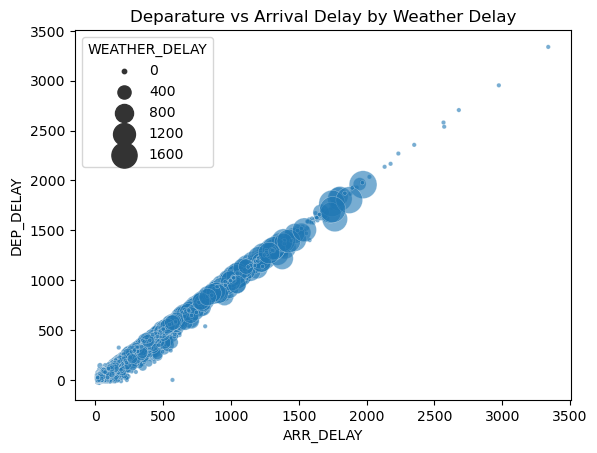

In [56]:
sns.scatterplot(x=df2['ARR_DELAY'], y=df2['DEP_DELAY'], size=df2['WEATHER_DELAY'], sizes=(10, 400),alpha=0.6).set_title('Deparature vs Arrival Delay by Weather Delay')

Text(0.5, 1.0, 'Deparature vs Arrival Delay by Carrier Delay')

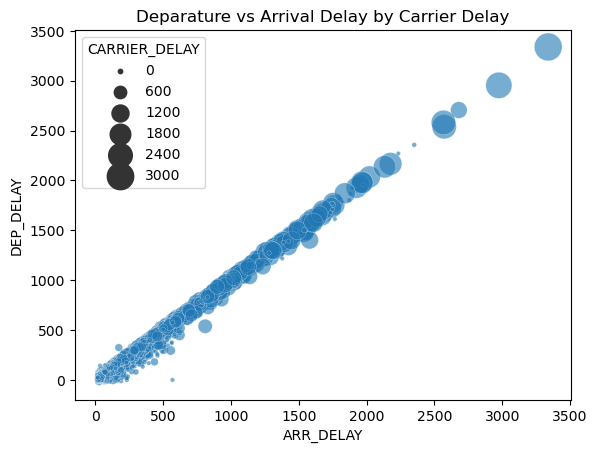

In [57]:
sns.scatterplot(x=df2['ARR_DELAY'], y=df2['DEP_DELAY'], size=df2['CARRIER_DELAY'], sizes=(10, 400),alpha=0.6).set_title('Deparature vs Arrival Delay by Carrier Delay')

Text(0.5, 1.0, 'Deparature vs Arrival Delay by Late Aircraft Delay')

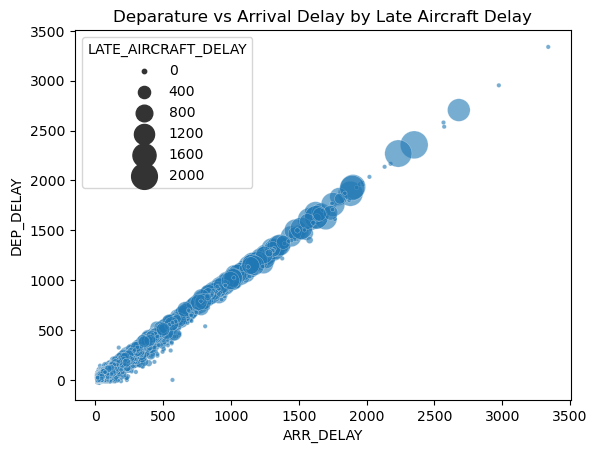

In [58]:
sns.scatterplot(x=df2['ARR_DELAY'], y=df2['DEP_DELAY'], size=df2['LATE_AIRCRAFT_DELAY'], sizes=(10, 400),alpha=0.6).set_title('Deparature vs Arrival Delay by Late Aircraft Delay')

**STEP 3 - PCA**

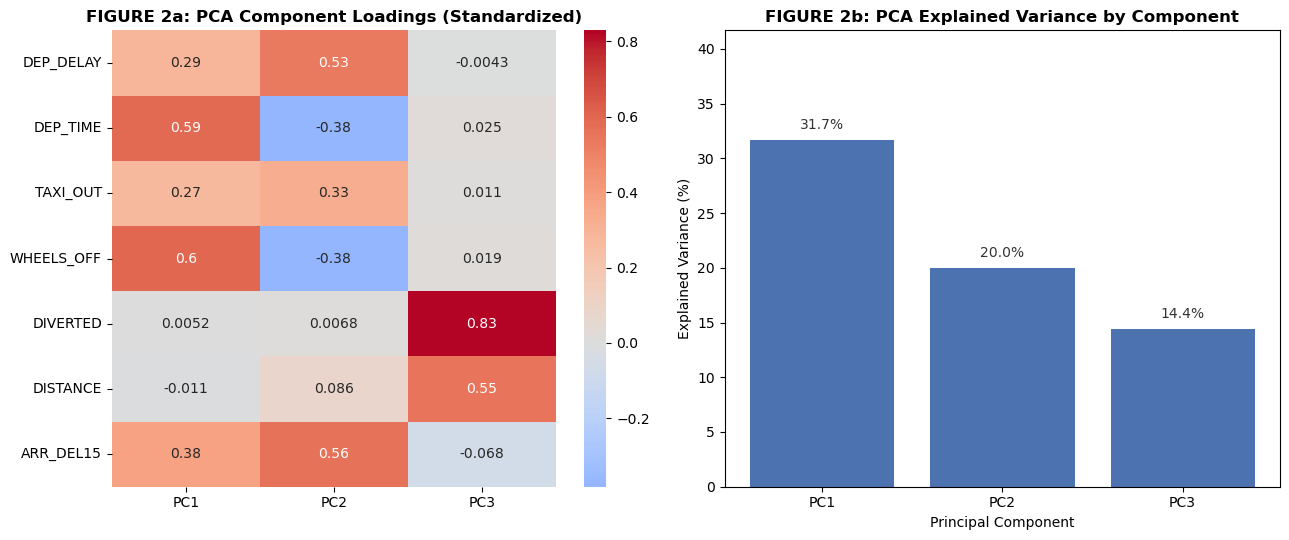

In [87]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['DEP_DELAY','DEP_TIME','TAXI_OUT','WHEELS_OFF','DIVERTED','DISTANCE','ARR_DEL15']
df2_nums = df2[num_cols].fillna(0)

scaler = StandardScaler()
df2_scaled = scaler.fit_transform(df2_nums)

pca = decomposition.PCA(n_components=3)
pca.fit(df2_scaled)

loadings = pd.DataFrame(pca.components_.T, index=num_cols,
                         columns=[f'PC{i+1}' for i in range(pca.n_components_)])

explained_variance = pca.explained_variance_ratio_
components = [f'PC{i+1}' for i in range(len(explained_variance))]

# One figure, two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: PCA loadings heatmap
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('FIGURE 2a: PCA Component Loadings (Standardized)', fontweight='bold')

# Right: Explained variance bar chart
bars = ax2.bar(components, explained_variance * 100, color='#4C72B0')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance (%)')
ax2.set_ylim(0, max(explained_variance * 100) + 10)
for bar, val in zip(bars, explained_variance):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{val*100:.1f}%', ha='center', fontsize=10, color='#333')
ax2.set_title('FIGURE 2b: PCA Explained Variance by Component', fontweight='bold')

plt.tight_layout()
plt.show()

Conclusions:

`PC1`:
- I interpret this by saying that the departure time and the wheels off the ground time affect the arrival delay. The Taxi Out time plays a role because it is also a part of the process and the dep delay is just a summary feature of how smoothly the departure time went

`PC2`:
- high PC2 scores mean bigger departure delays and higher chance of a 15+ minute arrival delay, somewhat independent of what time of day it is (in fact, slightly associated with earlier scheduled departure times once the other pattern is separated out).

`PCA3`:
- I think this is just isolating diverted flights and flight distance as their own pattern, since diverted flights only happen in specific cases.

**STEP 4 - Linear Regression**

In [60]:
cat_cols = ['OP_UNIQUE_CARRIER','ORIGIN_AIRPORT_ID','DEST_AIRPORT_ID']
cols_drop = ['ACTUAL_ELAPSED_TIME','CRS_ELAPSED_TIME','AIR_TIME','CRS_ARR_TIME','ARR_TIME','ARR_DELAY','YEAR','MONTH']
num_cols_flights = ['DEP_DELAY','DEP_TIME','TAXI_OUT','WHEELS_OFF','DIVERTED','DISTANCE','ARR_DEL15']
y = ['ARR_DEL15']

In [61]:
# Preparing the data for regression

# Creating dummy variable columns for every categorical column
df_ready = pd.get_dummies(df2, columns=cat_cols, dtype=int)
df_ready[num_cols_flights] = df2[num_cols_flights]
df_ready = df_ready.select_dtypes(include='number')
df_ready = df_ready.drop(columns=cols_drop)
df_ready = df_ready.fillna(0)

In [62]:
X = df_ready.drop(columns='ARR_DEL15')
Y = df_ready[y]
print(f"{sum(Y.isnull().sum())}")
print(f"{sum(X.isnull().sum())}")

0
0


PCA COMPONENT REGRESSION

In [77]:
from sklearn import linear_model, metrics

# Transform your scaled data into PCA component scores
pca_scores = pca.transform(df2_scaled)

pca_df = pd.DataFrame(pca_scores, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=df2.index)

# Fill target NaNs with 0 to match how predictors were handled
target = df2["ARR_DEL15"].fillna(0)

LinReg = linear_model.LinearRegression()
LinReg.fit(pca_df, target)

preds = LinReg.predict(pca_df)
mse = metrics.mean_squared_error(target, preds)
rmse_pca = np.sqrt(mse)
r2_pca = LinReg.score(pca_df, target)

print(rmse_pca)
print(LinReg.score(pca_df, target))  # R²

0.3502448806552062
0.2262037472557129


NUMERICAL MODEL

In [64]:
from sklearn import linear_model, metrics

df_nums = df_ready[num_cols_flights]
df_nums = df_nums.drop(columns='ARR_DEL15')

LinReg = linear_model.LinearRegression()
LinReg.fit(df_nums, Y)
preds_delay = LinReg.predict(df_nums)
mse_delay = metrics.mean_squared_error(Y, preds_delay)

rmse_delay_num = np.sqrt(mse_delay)
r2_num = LinReg.score(df_nums, Y)

print(mse_delay)
print(r2_num) 

0.10599990862457709
0.33136590122511456


CATEGORICAL MODEL

In [65]:
df_cat = df_ready.drop(columns=num_cols)
df_cat = df_ready.drop(columns='ARR_DEL15')

LinReg = linear_model.LinearRegression()
LinReg.fit(df_cat, Y)
preds_delay = LinReg.predict(df_cat)
mse_delay = metrics.mean_squared_error(Y, preds_delay)

rmse_delay_cat = np.sqrt(mse_delay)
r2_cat = LinReg.score(df_cat, Y)

print(mse_delay)
print(r2_cat) 

0.05245285455954065
0.6691339870791466


COMBINED REGRESSION MODEL

In [66]:
from sklearn import linear_model, metrics

LinReg = linear_model.LinearRegression()
LinReg.fit(X, Y)
preds_delay = LinReg.predict(X)
mse_delay = metrics.mean_squared_error(Y, preds_delay)

rmse_delay_comb = np.sqrt(mse_delay)
r2_comb = LinReg.score(X, Y)

print(mse_delay)
print(r2_comb)

0.05245285455954065
0.6691339870791466


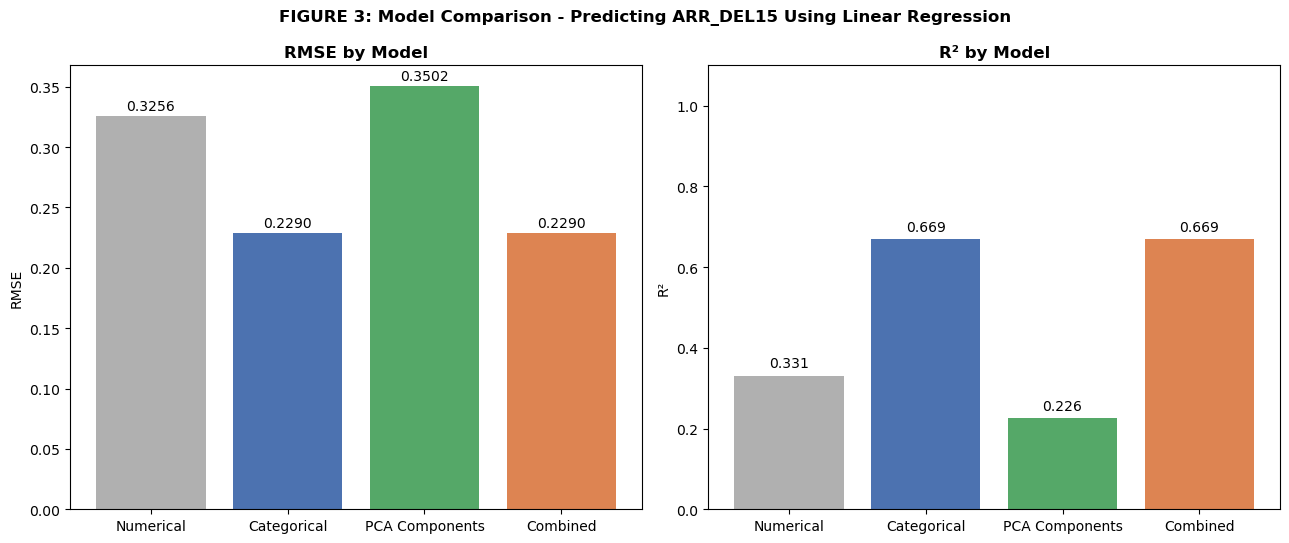

In [88]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Numerical', 'Categorical', 'PCA Components', 'Combined']
rmse = [rmse_delay_num, rmse_delay_cat,
        rmse_pca, rmse_delay_comb]
r2 = [r2_num, r2_cat, r2_pca, r2_comb]

colors = ['#B0B0B0', '#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

bars0 = axes[0].bar(models, rmse, color=colors)
axes[0].set_title('RMSE by Model', fontweight='bold')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars0, rmse):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.4f}', ha='center')

bars1 = axes[1].bar(models, r2, color=colors)
axes[1].set_title('R² by Model', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars1, r2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center')

fig.suptitle('FIGURE 3: Model Comparison - Predicting ARR_DEL15 Using Linear Regression', fontweight='bold')
plt.tight_layout()
plt.show()

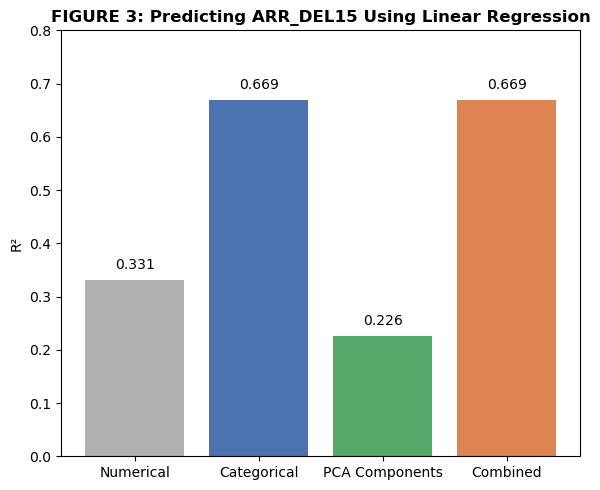

In [95]:
models = ['Numerical', 'Categorical', 'PCA Components', 'Combined']
r2 = [r2_num, r2_cat, r2_pca, r2_comb]

colors = ['#B0B0B0', '#4C72B0', '#55A868', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(models, r2, color=colors)
ax.set_title('FIGURE 3: Predicting ARR_DEL15 Using Linear Regression', fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, .8)
for bar, val in zip(bars, r2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.show()

**CONCLUSIONS**

`PCA COMPONENT MODEL`
- Uses PCA components of the numerical columns as predictors for delayed flights
- r2 of .75 suggests that the PCA components reliably explain the variablity of whats being predicted

`RAW NUMERICAL MODEL`
- Contains the raw numerical columns in the dataset that describe the departure delay, the taxi time, the takeoff time and other characteristics
- r2 score of .33 suggests a poor fit but also implies that there is some kind of relationship between some of the dependent variables

`CATEGORICAL MODEL`
- Contains dummy variables of the unique airlines, origins and destination of each flight
- r2 of .66 suggests there is some explainability of the variance

`Combined Model`
- Combines categorical dummy variables and numerical columns in a regression model to predict whether or not a given flight will be more than 15 minutes late
- r2 score of .67 suggests the features explain the variability decently well, but could use some improvement

While the PCA model can reasonably predict a delayed flight, improvements can be made. Next steps would be improving the model's performance via feature engineering and splitting the datasets up with training/testing subsets to produce a more accurate model

**Second Dataset Regression**

In [68]:
cat_cols = ['uniquecarrier', 
       'originairportid', 'destairportid']

num_cols = ['marketshareorigin', 'marketsharedest','capacity', 'loadfactor',
       'numflights','dayofmonth', 'dayofweek', 'scheduledhour','distance','windspeed', 'windspeedsquare','windgustspeed','originmetropop', 'originmetrogdppercapita', 'destmetropop',
       'destmetrogdppercapita','temperature','hhiorigin',
       'hhidest']

cat_cols_stay = ['nonhubairportorigin', 'smallhubairportorigin',
       'mediumhubairportorigin', 'largehubairportorigin', 'nonhubairportdest',
       'smallhubairportdest', 'mediumhubairportdest', 'largehubairportdest',
       'nonhubairlineorigin', 'smallhubairlineorigin',
       'mediumhubairlineorigin', 'largehubairlineorigin', 'nonhubairlinedest',
       'smallhubairlinedest', 'mediumhubairlinedest', 'largehubairlinedest','temp_ninfty_n10', 'temp_n10_0',
       'temp_0_10', 'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty','monopolyroute','windgustdummy', 
       'raindummy', 'raintracedummy', 'snowdummy', 'snowtracedummy']

In [69]:
# dummies = pd.get_dummies(df[cat_cols], columns=cat_cols, dtype=int)

df_ready2 = pd.concat([df[num_cols], df[cat_cols_stay]], axis=1)
df_ready2 = df_ready2.fillna(0)

In [70]:
df_ready2['arr_del15'] = np.where(df['arrdelay'] > 15, 1, 0)
y = df_ready2['arr_del15']

In [71]:
X = df_ready2.drop(columns='arr_del15')
Y = y
print(f"Y missing: {Y.isnull().sum()}")
print(f"X missing (per column):\n{X.isnull().sum()}")
print(f"X missing (total): {X.isnull().sum().sum()}")

Y missing: 0
X missing (per column):
marketshareorigin          0
marketsharedest            0
capacity                   0
loadfactor                 0
numflights                 0
dayofmonth                 0
dayofweek                  0
scheduledhour              0
distance                   0
windspeed                  0
windspeedsquare            0
windgustspeed              0
originmetropop             0
originmetrogdppercapita    0
destmetropop               0
destmetrogdppercapita      0
temperature                0
hhiorigin                  0
hhidest                    0
nonhubairportorigin        0
smallhubairportorigin      0
mediumhubairportorigin     0
largehubairportorigin      0
nonhubairportdest          0
smallhubairportdest        0
mediumhubairportdest       0
largehubairportdest        0
nonhubairlineorigin        0
smallhubairlineorigin      0
mediumhubairlineorigin     0
largehubairlineorigin      0
nonhubairlinedest          0
smallhubairlinedest        0
medium

**FINAL CONCLUSIONS**

This dataset is a great real world dataset that deals with class imbalances and cleanliness issues. That being said, the foundation of potential model building can be done and with improvements, predictions of delayed flights should be possible. There are relationships that can be visualized and proven via heatmaps and scatter plots, and preliminary model building show promising results.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

**ANSWER - PAGE 142**

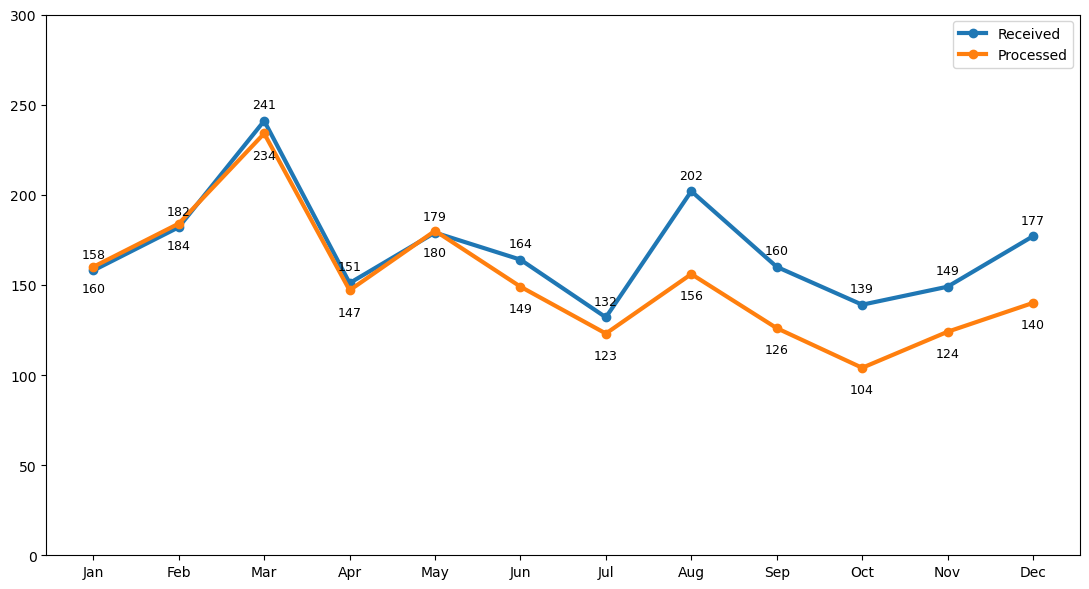

In [72]:
import matplotlib.pyplot as plt

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
received = [158,182,241,151,179,164,132,202,160,139,149,177]
processed = [160,184,234,147,180,149,123,156,126,104,124,140]

plt.figure(figsize=(11, 6))
for data, name, offset in [(received, "Received", 7), (processed, "Processed", -14)]:
    plt.plot(months, data, marker="o", linewidth=3, label=name)
    for month, value in zip(months, data):
        plt.text(month, value + offset, value, ha="center", fontsize=9)

plt.ylim(0, 300)
plt.legend()
plt.tight_layout()